# Часть 1. Работа с исходными данными 

## 1-й Шаг портируем библиотеки 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

## 2-й Шаг читаем файл 

In [2]:
df = pd.read_csv('users_activity.csv')

df.head()

,user_id,date,signup_date,country,device,session_duration,events,purchases,revenue
0,368,2026-01-01,2025-12-29,FR,iOS,6,11,1,68.80
1,940,2026-01-01,2025-12-21,USA,Android,22,15,1,36.87
2,652,2026-01-01,2025-12-20,USA,Android,18,18,0,51.30
3,604,2026-01-01,2025-12-05,DE,iOS,11,2,0,26.91
4,450,2026-01-01,2025-12-25,RU,iOS,11,13,0,38.06


## 3-й Шаг первичное преобразование данных 

In [3]:
df['date'] = df['date'].astype("datetime64[ns]") # преобразуем строки в время
df['signup_date'] = df['signup_date'].astype("datetime64[ns]") # преобрахуем строки в время

## 4-й Шаг находим разницу между датой активности и датой появления пользователя это будет retention_day

In [5]:
df.loc[:, 'retention_day'] = (df.date - df.signup_date).dt.days

## 5-й Шаг считаем добавляем столбец date_start - это день начиная с которого нам интересно посчитать показатели 

In [6]:
df['start_date'] = '2025-10-12'

df['start_date'] = df['start_date'].astype('datetime64[ns]')

## 6-й Шаг рассчитываем количество месяцев прошедших после start_date после которых пользователь совершил активность 

In [7]:
df['month'] = (df.date.dt.year - df.start_date.dt.year) * 12 + (df.date.dt.month - df.start_date.dt.month)

## 7-й Шаг после того как мы нашли кол-во прошедших месяцев мы можем посчитать MAU 

In [9]:
df['MAU'] = df.groupby('month')['user_id'].transform('nunique')

## 8-й Шаг рассчитаем количество дней прошедших с start_date до активности пользователя 

In [11]:
df['last_days'] = (df.date - df.start_date).dt.days

## 9-й Шаг расчитываем DAU для каждого прошедшего дня в last_days 

In [18]:
df['DAU'] = df.groupby('last_days')['user_id'].transform('nunique')

DAU = df.groupby('last_days')['user_id'].transform('nunique')

## 10-й Шаг расчитываем долю новых пользователей для каждого дня 

In [19]:
# 1. Считаем количество новичков (тех, кто зашел в день регистрации) для каждого дня
new_users_by_day = df[df['date'] == df['signup_date']].groupby('last_days')['user_id'].nunique()

df['Share of new users'] = round((new_users_by_day / DAU) * 100)

## 11-й Шаг рассчитываем Retetion Rate 

In [22]:
min_day = df['last_days'].min() # min день 

cohort_size = df[df['last_days'] == min_day]['user_id'].nunique() # размер когорты

total_active = df.groupby('last_days')['user_id'].transform('nunique')
new_users = df[df['date'] == df['signup_date']].groupby('last_days')['user_id'].transform('nunique')

returning_users = total_active - new_users

# 4. Считаем Retention
df['Retention'] = (returning_users / cohort_size) * 100

## 12-й Шаг рассчитываем ARPU 

In [26]:
ARPU = df['revenue'].sum() / df['user_id'].nunique() # средний доход от каждого пользователя 

## 13-й Шаг рассчитываем ARPPU 

In [28]:
ARPPU = df[df['purchases'] > 0]['revenue'].sum() / df[df['purchases'] > 0]['user_id'].nunique() # средний доход только на платящего пользователя 

## 14-й шаг рассчитываем GMV(выручку) 

In [ ]:
GMV = round(df['revenue'].sum())

## 15-й шаг рассчитываем медианные значения 

In [ ]:
median_purchases = df['purchases'].median()
median_session_duration = df['session_duration'].median()

# Часть 2. Визуализация 

## Гистограма с количеством киентов по странам 

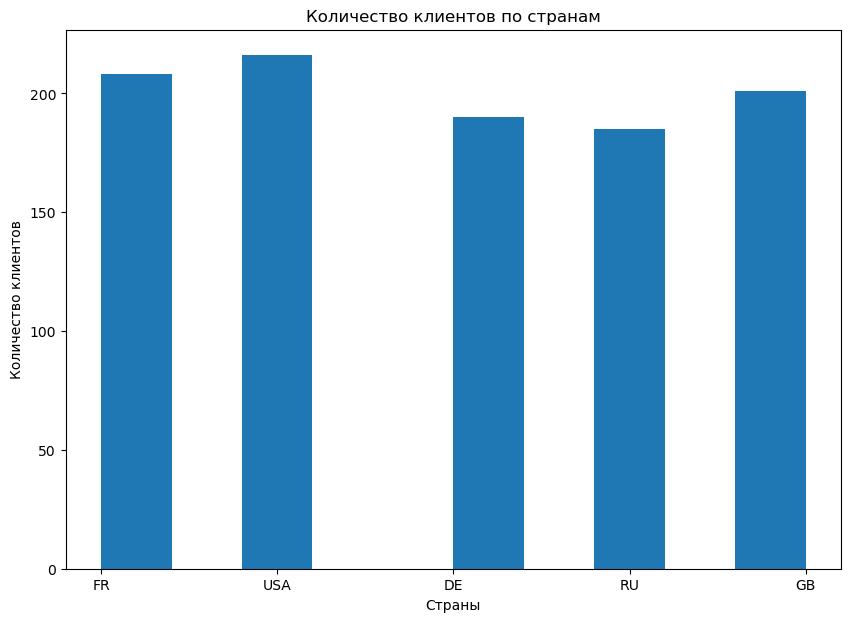

In [30]:
plt.figure(figsize=(10, 7))

plt.hist(df['country'])

plt.title('Количество клиентов по странам') 
plt.xlabel('Страны')
plt.ylabel('Количество клиентов')
plt.show()

## Гистограма количество пользователей взависимости от устройства 

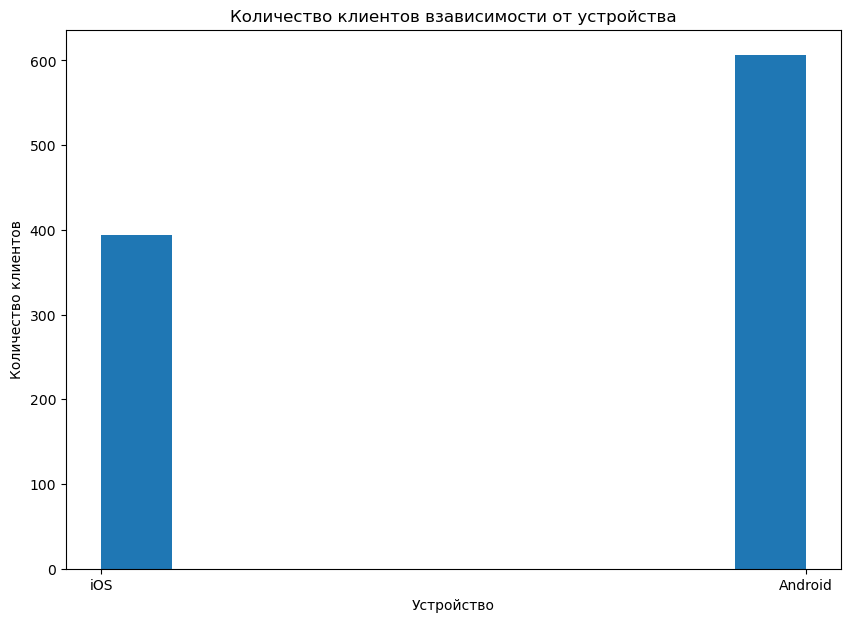

In [32]:
plt.figure(figsize=(10, 7))

plt.hist(df['device'])

plt.title('Количество клиентов взависимости от устройства')

plt.xlabel('Устройство')
plt.ylabel('Количество клиентов')
plt.show()